In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from torchvision import transforms
from torchvision.models import resnet50
from torchvision.datasets import ImageFolder

from torch.utils.data import DataLoader
from torch.nn import CrossEntropyLoss
from torch.optim import AdamW


In [2]:
# GPU
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu")

print("Dispositivo:", device)

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

Dispositivo: cuda
NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [3]:
# TRANSFORMACIONES
transform = transforms.Compose([

    transforms.Resize(256),

    transforms.CenterCrop(224),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )

])

In [4]:
# DATASET
train_folder = ImageFolder(
    "./archive/data1a/training",
    transform=transform)

val_folder = ImageFolder(
    "./archive/data1a/validation",
    transform=transform)

print(train_folder.classes)
print(train_folder.class_to_idx)

# DATALOADER
train_loader = DataLoader(
    train_folder,
    batch_size=16,
    shuffle=True)

val_loader = DataLoader(
    val_folder,
    batch_size=16,
    shuffle=False)

model = resnet50(
    weights="IMAGENET1K_V1")

['00-damage', '01-whole']
{'00-damage': 0, '01-whole': 1}


In [5]:
# Congelar toda la red
for param in model.parameters():

    param.requires_grad = False

# Cambiar capa final
model.fc = nn.Sequential(

    nn.Dropout(0.5),

    nn.Linear(
        2048,
        2
    )

)


In [6]:
# Descongelar última parte
for param in model.layer4.parameters():

    param.requires_grad = True

for param in model.fc.parameters():

    param.requires_grad = True


In [7]:
# Mandar a GPU
model = model.to(device)

In [8]:
# Revisar capas entrenables
print("\nCapas entrenables:")

for name,param in model.named_parameters():

    if param.requires_grad:

        print(name)


Capas entrenables:
layer4.0.conv1.weight
layer4.0.bn1.weight
layer4.0.bn1.bias
layer4.0.conv2.weight
layer4.0.bn2.weight
layer4.0.bn2.bias
layer4.0.conv3.weight
layer4.0.bn3.weight
layer4.0.bn3.bias
layer4.0.downsample.0.weight
layer4.0.downsample.1.weight
layer4.0.downsample.1.bias
layer4.1.conv1.weight
layer4.1.bn1.weight
layer4.1.bn1.bias
layer4.1.conv2.weight
layer4.1.bn2.weight
layer4.1.bn2.bias
layer4.1.conv3.weight
layer4.1.bn3.weight
layer4.1.bn3.bias
layer4.2.conv1.weight
layer4.2.bn1.weight
layer4.2.bn1.bias
layer4.2.conv2.weight
layer4.2.bn2.weight
layer4.2.bn2.bias
layer4.2.conv3.weight
layer4.2.bn3.weight
layer4.2.bn3.bias
fc.1.weight
fc.1.bias


In [10]:
# FUNCIÓN ENTRENAMIENTO
def training_loop(
        optimizer,
        loss_fn,
        epochs=30,
        patience=6
):

    train_losses=[]
    train_acc=[]
    val_losses=[]
    val_acc=[]

    best_accuracy=0

    patience_count=0

    for epoch in range(epochs):

        print(
            f"\nEpoch {epoch+1}/{epochs}")


       
        # TRAIN       
        model.train()

        total_loss=0
        correct=0
        total=0

        for data,target in train_loader:

            data=data.to(device)
            target=target.to(device)
            optimizer.zero_grad()
            output=model(data)

            loss=loss_fn(
                output,
                target
            )

            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            pred=output.argmax(1)
            
            correct += (
                pred==target
            ).sum().item()

            total += target.size(0)

        train_loss=total_loss/len(train_loader)
        train_accuracy=correct/total
        train_losses.append(train_loss)
        train_acc.append(train_accuracy)

        print(
            f"Train Loss: {train_loss:.4f} | "
            f"Accuracy: {train_accuracy:.4f}")

        
        # VALIDACION   
        model.eval()

        val_loss_total=0
        val_correct=0
        val_total=0

        with torch.no_grad():

            for data,target in val_loader:

                data=data.to(device)
                target=target.to(device)
                output=model(data)

                loss=loss_fn(
                    output,
                    target
                )

                val_loss_total += loss.item()
                pred=output.argmax(1)

                val_correct += (
                    pred==target
                ).sum().item()

                val_total += target.size(0)

        val_loss=val_loss_total/len(val_loader)
        val_accuracy=val_correct/val_total
        val_losses.append(val_loss)
        val_acc.append(val_accuracy)

        print(
            f"Val Loss: {val_loss:.4f} | "
            f"Accuracy: {val_accuracy:.4f}"
        )



        # Guardar mejor modelo
        if val_accuracy > best_accuracy:
            best_accuracy=val_accuracy
            torch.save(
                model.state_dict(),
                "best_damage_model.pth"
            )
            print(
                "Mejor modelo guardado:",
                best_accuracy
            )
            patience_count=0

        else:

            patience_count += 1

            if patience_count >= patience:
                print(
                    "Early stopping"
                )
                break

    return (
        train_losses,
        train_acc,
        val_losses,
        val_acc)


# ENTRENAMIENTO
optimizer = AdamW(

    filter(
        lambda p:p.requires_grad,
        model.parameters()
    ),
    lr=0.0001, weight_decay=0.01)

loss_fn = CrossEntropyLoss()

all_train_loss, all_train_accuracy, all_val_loss, all_val_accuracy = training_loop(

    optimizer,
    loss_fn,
    epochs=30,
    patience=6)



Epoch 1/30
Train Loss: 0.2614 | Accuracy: 0.8951
Val Loss: 0.1499 | Accuracy: 0.9478
Mejor modelo guardado: 0.9478260869565217

Epoch 2/30
Train Loss: 0.0829 | Accuracy: 0.9663
Val Loss: 0.1216 | Accuracy: 0.9500
Mejor modelo guardado: 0.95

Epoch 3/30
Train Loss: 0.0427 | Accuracy: 0.9875
Val Loss: 0.1742 | Accuracy: 0.9348

Epoch 4/30
Train Loss: 0.0315 | Accuracy: 0.9913
Val Loss: 0.1784 | Accuracy: 0.9413

Epoch 5/30
Train Loss: 0.0209 | Accuracy: 0.9935
Val Loss: 0.1690 | Accuracy: 0.9348

Epoch 6/30
Train Loss: 0.0158 | Accuracy: 0.9940
Val Loss: 0.1664 | Accuracy: 0.9522
Mejor modelo guardado: 0.9521739130434783

Epoch 7/30
Train Loss: 0.0224 | Accuracy: 0.9902
Val Loss: 0.1769 | Accuracy: 0.9413

Epoch 8/30
Train Loss: 0.0216 | Accuracy: 0.9957
Val Loss: 0.1730 | Accuracy: 0.9478

Epoch 9/30
Train Loss: 0.0049 | Accuracy: 0.9995
Val Loss: 0.2164 | Accuracy: 0.9500

Epoch 10/30
Train Loss: 0.0075 | Accuracy: 0.9967
Val Loss: 0.2198 | Accuracy: 0.9370

Epoch 11/30
Train Loss: 0.

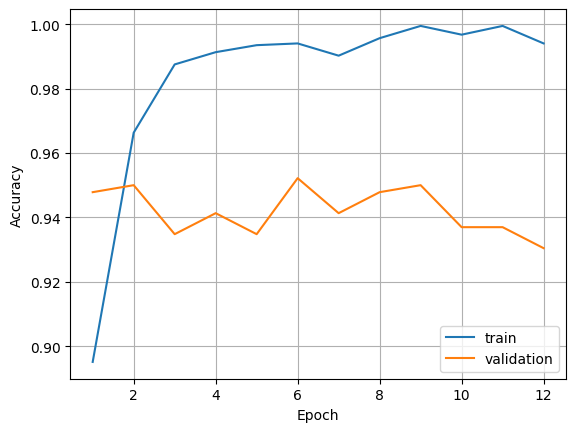

In [11]:
# CARGAR MEJOR MODELO
model.load_state_dict(
    torch.load(
        "best_damage_model.pth"
    )

)
model.eval()

# GRAFICO ACCURACY
sns.lineplot(
    x=range(1,len(all_train_accuracy)+1),
    y=all_train_accuracy,
    label="train")

sns.lineplot(
    x=range(1,len(all_val_accuracy)+1),
    y=all_val_accuracy,
    label="validation")

plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.grid()
plt.show()

In [12]:
# PREDICCION AUTO REAL
img = Image.open(
    r"C:\Users\alons\OneDrive\Desktop\proyecto2\autodañado.jpg"
).convert("RGB")

img_t = transform(img)
batch = img_t.unsqueeze(0).to(device)

with torch.no_grad():
    logits=model(batch)

    probs=F.softmax(
        logits,
        dim=1)

resultado=pd.DataFrame(

    probs.cpu().numpy(),

    columns=[
        "00-damage",
        "01-whole"])
print(resultado)


# Clase final
prediction = probs.argmax(1).item()
print(
    "\nPredicción:",
    train_folder.classes[prediction])

print(
    "Confianza:",
    probs[0][prediction].item())

   00-damage  01-whole
0   0.981653  0.018347

Predicción: 00-damage
Confianza: 0.9816532731056213
